In [2]:
import pandas as pd

# Load Data

NOTE - Some cleaning was required to account for Facebook's rebranded to Meta. Can copy that code over here if needed. For now, I am loading the dataset with this problem fixed.

### Daily Data

In [2]:
import pandas as pd
df_daily_data = pd.read_csv('transformed_daily_data/Cleaned_New_2026_05_18.csv')
df_daily_data = df_daily_data.sort_values(by=['ticker', 'timestamp'])
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.09,134.090,131.2500,133.370,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.31,132.600,130.7700,132.400,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.19,134.820,133.1900,133.900,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.76,133.930,131.7600,131.870,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.27,131.840,129.3000,131.420,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4986892,2026-04-27,NaN,2.29,2.290,1.8500,1.850,9.317473e+04,2.1023,1094.0
4986893,2026-04-28,NaN,2.01,2.110,1.7800,1.795,2.693652e+05,1.9115,1846.0
4986894,2026-04-29,NaN,1.86,1.860,1.6000,1.605,1.364121e+05,1.6963,1155.0
4986895,2026-04-30,NaN,1.60,1.850,1.5801,1.770,1.013014e+05,1.6733,858.0


In [3]:
df_daily_data['ticker'].value_counts()

ticker
A       1254
MFA     1254
MEC     1254
MED     1254
MEDP    1254
        ... 
QXL        2
DYNC       1
COAG       1
UCFI       1
SPTX       1
Name: count, Length: 5037, dtype: int64

Filtering

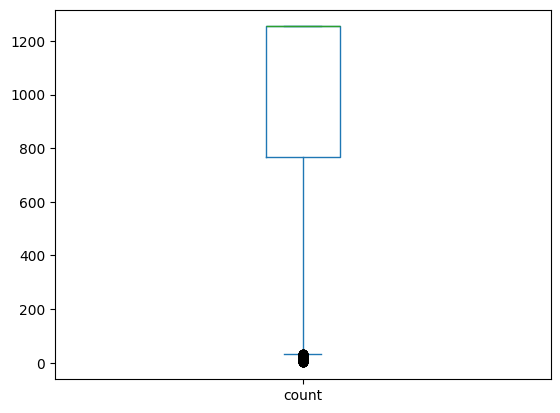

In [4]:
import matplotlib.pyplot as plt

df_daily_data['ticker'].value_counts().plot.box()

plt.show()

In [5]:
thresholds = [1200, 1220, 1229, 1230, 1240, 1250, 1253, 1254]

ticker_counts = df_daily_data['ticker'].value_counts()

for t in thresholds:
    count = (ticker_counts >= t).sum()
    print(f">={t}: {count}")

>=1200: 3145
>=1220: 3068
>=1229: 3033
>=1230: 3025
>=1240: 2985
>=1250: 2924
>=1253: 2870
>=1254: 2804


My original methodology for filling missing days was to find stocks in which no more than 2% of days were missing, AND there were no consecutive missing days, AND none of the missing days were on Monday or Friday. Any remaining missing days would then be forward-filled with the previous day.

This was feasible with a volume filter applied, but since there is none right now, this would be time prohibitive. Therefore, I will tolerate zero missing days. May change this later.

For transformation, we'll make a copy.

In [6]:
df_cleaned_daily = df_daily_data.copy()

In [7]:
import pandas as pd

ticker_counts = df_cleaned_daily.set_index('timestamp')['ticker'].value_counts()

mask = df_cleaned_daily['ticker'].isin(ticker_counts[ticker_counts >= 1254].index)

df_cleaned_daily = df_cleaned_daily[mask]

df_cleaned_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0


In [8]:
df_cleaned_daily['ticker'].value_counts()

ticker
A       1254
ONCY    1254
OM      1254
OMC     1254
OMCL    1254
        ... 
FATE    1254
FBIO    1254
FBIZ    1254
FBK     1254
ZYME    1254
Name: count, Length: 2804, dtype: int64

Add moving averages - A later question asks for this, so add it now.

In [9]:
df_cleaned_daily['SMA10'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(10).mean())
df_cleaned_daily['SMA20'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(20).mean())
df_cleaned_daily['SMA50'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(50).mean())
df_cleaned_daily['SMA100'] = df_cleaned_daily.groupby('ticker')['close'].transform(lambda x: x.rolling(100).mean())

Add next day and previous day stats here.

In [10]:
df_cleaned_daily['pct_change_from_prev'] = (
    df_cleaned_daily.groupby('ticker')['close']
    .pct_change() * 100
)

df_cleaned_daily['next_close_pct_change'] = (
    (
        df_cleaned_daily.groupby('ticker')['close']
        .shift(-1)
        / df_cleaned_daily['close']
    - 1
    ) * 100
)

In [11]:
df_cleaned_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0,NaN,NaN,NaN,NaN,NaN,-0.727300
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0,NaN,NaN,NaN,NaN,-0.727300,1.132931
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0,NaN,NaN,NaN,NaN,1.132931,-1.516057
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0,NaN,NaN,NaN,NaN,-1.516057,-0.341245
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0,NaN,NaN,NaN,NaN,-0.341245,-2.115355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985939,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041
4985942,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0,27.985,27.2975,25.3379,24.8915,-1.042041,-3.376906


In [12]:
df_cleaned_daily = df_cleaned_daily.dropna()

In [13]:
df_cleaned_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change
99,2021-09-24,A,172.090,173.080,171.2000,172.40,1.041912e+06,172.4244,15834.0,172.590,174.7785,164.3732,152.4526,-0.214158,-3.491879
100,2021-09-27,A,171.060,171.150,164.2629,166.38,1.419754e+06,166.1472,25590.0,172.020,174.4070,164.7222,152.7827,-3.491879,-3.894699
101,2021-09-28,A,164.190,164.330,158.7900,159.90,2.541015e+06,160.4667,41170.0,170.768,173.5655,164.9686,153.0577,-3.894699,0.062539
102,2021-09-29,A,161.390,161.805,159.8300,160.00,1.268214e+06,160.5194,22512.0,169.389,172.7920,165.1826,153.3187,0.062539,-1.543750
103,2021-09-30,A,161.230,162.480,157.4600,157.53,1.558941e+06,158.5686,21666.0,167.814,171.8960,165.3542,153.5753,-1.543750,-0.977592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985938,2026-04-24,ZYME,27.510,28.300,26.9300,28.10,5.705914e+05,27.9745,11600.0,27.606,26.6725,24.9355,24.8115,2.442581,1.637011
4985939,2026-04-27,ZYME,27.930,29.750,27.9300,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.9200,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.7700,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041


In [14]:
df_daily_five_years = df_cleaned_daily.copy()

In [15]:
df_daily_two_years = df_daily_five_years[df_daily_five_years['timestamp'] >= '2024-04-30']

My raw daily dataset ran from 2021/05/05 to 2026/05/01.

When SMAs are applied up to 100 days, the first 99 days will be null as there are insufficient days to calculate SMA100, and consequently will have to be dropped.

Similarly, if next_day metrics are calculated, the final day will have to be dropped as there will be no next day.

With both of these changes, the new span will be 2021/07/15 to 2026/04/30.

### Hourly Data

In [13]:
df_hourly_data

NameError: name 'df_hourly_data' is not defined

# LOAD LIVE DATA?

# EDA TASKS

2. Plot long-term stock data over multiple years.
Create an interactive graph that allows the user to view different time ranges.

This should probably be a Streamlit app then?

3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.

In [16]:
daily_aapl_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'AAPL']
daily_amzn_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'AMZN']
daily_meta_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'META']
daily_nflx_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'NFLX']
daily_nvda_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'NVDA']
daily_googl_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'GOOGL']

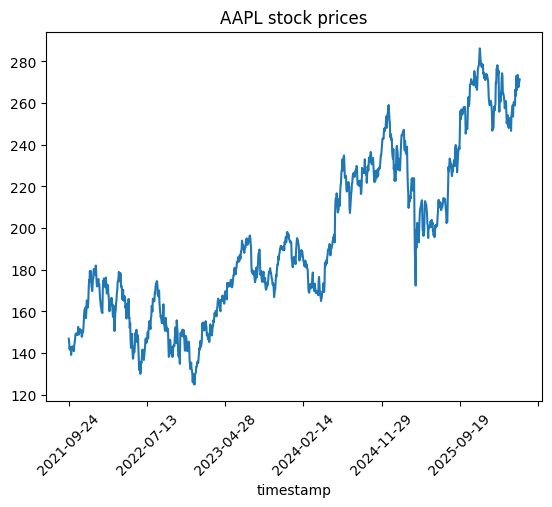

In [17]:
import matplotlib.pyplot as plt

daily_aapl_five_years = df_daily_five_years[df_daily_five_years['ticker'] == 'AAPL']

daily_aapl_five_years.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AAPL stock prices')
plt.show()

Something I was curious about?

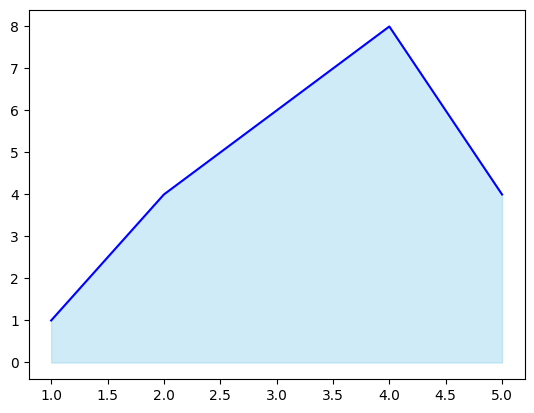

In [20]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 6, 8, 4]

plt.plot(x, y, color='blue') # Optional: plot the line itself
plt.fill_between(x, y, color='skyblue', alpha=0.4) # Fill area below
plt.show()

4. Add moving averages to the stock charts, such as:
○ SMA20 and SMA50, or
○ SMA50 and SMA150
These should be overlaid on the main stock price chart.

These metrics were created at an earlier stage.

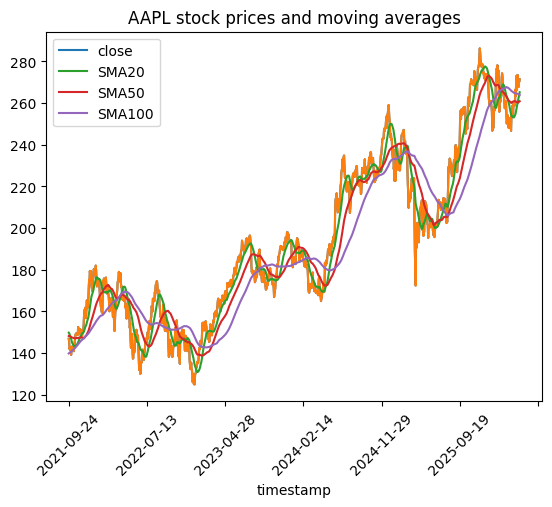

In [21]:
daily_aapl_five_years.set_index('timestamp')['close'].plot()


plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['close'])
plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['SMA20'], label='SMA20')
plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['SMA50'], label='SMA50')
plt.plot(daily_aapl_five_years['timestamp'], daily_aapl_five_years['SMA100'], label='SMA100')
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AAPL stock prices and moving averages')
plt.legend()
plt.show()

5. Create a table for five stocks. Use default examples such as FAANG stocks plus
NVIDIA, but allow the user to change them.

For each stock, calculate the historical probability that the next day is positive if the
current day changes by:
+2%, +3%, +4%, +5%, and +6%.
Example: if Apple rises 5% today, what is the historical probability that the next day
closes positive?
Use the last 2 years of historical data.

I'll make the default here for now.

Will have to make a dataframe in the cleaning stage, showing by stock these probabilites, one for each column.

User changeability will be added to the Streamlit when I reach that point.

For each stock, calculate the historical probability that the next day is positive if the
current day changes by:
+2%, +3%, +4%, +5%, and +6%.
Example: if Apple rises 5% today, what is the historical probability that the next day
closes positive?


In [156]:
prev_change_condition = (daily_aapl_two_years['pct_change_from_prev'] >=2)
next_change_condition = (daily_aapl_two_years['next_close_pct_change'] >=0)
full_condition = prev_change_condition & next_change_condition

matching_days = full_condition.sum()
total_prev_days = prev_change_condition.sum()

full_condition_pct = matching_days / total_prev_days
full_condition_pct

np.float64(0.6904761904761905)

Now adapt this with variables.

In [24]:
daily_aapl_two_years = df_daily_two_years[df_daily_two_years['ticker'] == 'AAPL']

AAPL alone

In [25]:
thresholds = 2, 3, 4, 5, 6

for threshold in thresholds:
    prev_change_condition = (daily_aapl_two_years['pct_change_from_prev'] >= threshold)
    next_change_condition = (daily_aapl_two_years['next_close_pct_change'] >=0)
    full_condition = prev_change_condition & next_change_condition
    
    matching_days = full_condition.sum()
    total_prev_days = prev_change_condition.sum()
    
    full_condition_pct = matching_days / total_prev_days
    
    print(f"Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")
    #full_condition_pct

Probability of a positive change the day after a 2% increase: 0.690
Probability of a positive change the day after a 3% increase: 0.667
Probability of a positive change the day after a 4% increase: 0.444
Probability of a positive change the day after a 5% increase: 0.600
Probability of a positive change the day after a 6% increase: 0.667


Wrote this nested for loop myself, calculating logic somewhat incorrect.

In [22]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'GOOGL']

thresholds = 2, 3, 4, 5, 6

for ticker in ticker_list:
    for threshold in thresholds:
        prev_change_condition = (df_daily_five_years['pct_change_from_prev'] >= threshold)
        next_change_condition = (df_daily_five_years['next_close_pct_change'] >=0)
        full_condition = prev_change_condition & next_change_condition
        
        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()
        
        full_condition_pct = matching_days / total_prev_days
        
        print(f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")


AAPL: Probability of a positive change the day after a 2% increase: 0.488
AAPL: Probability of a positive change the day after a 3% increase: 0.486
AAPL: Probability of a positive change the day after a 4% increase: 0.483
AAPL: Probability of a positive change the day after a 5% increase: 0.481
AAPL: Probability of a positive change the day after a 6% increase: 0.478
GOOGL: Probability of a positive change the day after a 2% increase: 0.488
GOOGL: Probability of a positive change the day after a 3% increase: 0.486
GOOGL: Probability of a positive change the day after a 4% increase: 0.483
GOOGL: Probability of a positive change the day after a 5% increase: 0.481
GOOGL: Probability of a positive change the day after a 6% increase: 0.478


In [ ]:
for ticker in ticker_list:
    ticker_df = df_daily_five_years[df_daily_five_years['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        matching_days = (prev_change_condition & next_change_condition).sum()
        total_prev_days = prev_change_condition.sum()

        full_condition_pct = (matching_days / total_prev_day

        print(f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}")

Wrote the above one myself. Below adapted with assistance.

In [52]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

thresholds = 2, 3, 4, 5, 6, 10, 20


for ticker in ticker_list:
    ticker_df = df_daily_five_years[
        df_daily_five_years['ticker'] == ticker
    ]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(
                f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}"
            )
        else:
            print(
                f"{ticker}: >>>> No days with a {threshold}% increase <<<<"
            )

AAPL: Probability of a positive change the day after a 2% increase: 55.172
AAPL: Probability of a positive change the day after a 3% increase: 52.273
AAPL: Probability of a positive change the day after a 4% increase: 42.105
AAPL: Probability of a positive change the day after a 5% increase: 62.500
AAPL: Probability of a positive change the day after a 6% increase: 66.667
AAPL: Probability of a positive change the day after a 10% increase: 0.000
AAPL: >>>> No days with a 20% increase <<<<
NVDA: Probability of a positive change the day after a 2% increase: 53.898
NVDA: Probability of a positive change the day after a 3% increase: 53.158
NVDA: Probability of a positive change the day after a 4% increase: 52.542
NVDA: Probability of a positive change the day after a 5% increase: 55.882
NVDA: Probability of a positive change the day after a 6% increase: 55.814
NVDA: Probability of a positive change the day after a 10% increase: 42.857
NVDA: Probability of a positive change the day after a 

Can I make the calculations save to a dataframe instead?

In [ ]:
#ticker_list = df_daily_five_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META']

thresholds = 2, 3, 4, 5, 6, 10, 20


for ticker in ticker_list:
    ticker_df = df_daily_five_years[
        df_daily_five_years['ticker'] == ticker
    ]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(
                f"{ticker}: Probability of a positive change the day after a {threshold}% increase: {full_condition_pct:.3f}"
            )
        else:
            print(
                f"{ticker}: >>>> No days with a {threshold}% increase <<<<"
            )

In [ ]:
dftest = pd.DataFrame()
dftest['ticker'] = 

Now can I condense it?

In [173]:
name = "Python"
print(f"Welcome to {{{name}}}")

Welcome to {Python}


Probability of a positive change after a 2% increase: Python


In [163]:
# ticker_list = df_daily_five_years['ticker'].unique().tolist()

# for ticker in ticker_list

# for threshold in threshold_list

In [52]:
len(daily_aapl_two_years[daily_aapl_two_years['pct_change_from_prev'] >=5])

5

In [53]:
len(daily_aapl_two_years[daily_aapl_two_years['pct_change_from_prev'] >=6])

3

In [ ]:
next_change_thresholds = [2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6]

In [30]:
daily_aapl_two_years

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,change_from_prev_2
10617,2024-04-30,AAPL,173.330,174.990,170.00,170.33,6.582478e+07,172.1418,647476.0,168.482,169.6215,172.8392,181.3503,-1.827089,-0.604709,0
10618,2024-05-01,AAPL,169.580,172.705,169.11,169.30,4.938718e+07,170.7198,648626.0,168.612,169.6040,172.5940,181.1201,-0.604709,2.203190,0
10619,2024-05-02,AAPL,172.510,173.415,170.89,173.03,9.421152e+07,174.5241,944119.0,169.211,169.8145,172.4082,180.9077,2.203190,5.981622,1
10620,2024-05-03,AAPL,186.645,187.000,182.66,183.38,1.632241e+08,184.3674,1468505.0,171.049,170.5045,172.3884,180.7844,5.981622,-0.910677,1
10621,2024-05-06,AAPL,182.354,184.200,180.42,181.71,7.831967e+07,181.8711,898763.0,172.636,171.1675,172.3722,180.6697,-0.910677,0.379726,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11114,2026-04-24,AAPL,272.755,273.060,269.65,271.06,3.814749e+07,270.8897,593210.0,267.497,261.3985,260.1454,264.3281,-0.866767,-1.272781,0
11115,2026-04-27,AAPL,266.090,268.360,265.07,267.61,4.124462e+07,267.1775,513133.0,268.338,262.3390,260.2630,264.1732,-1.272781,1.158402,0
11116,2026-04-28,AAPL,272.335,273.230,268.66,270.71,4.001629e+07,270.5517,579937.0,269.526,263.5430,260.5616,264.0184,1.158402,-0.199475,0
11117,2026-04-29,AAPL,267.550,271.040,267.04,270.17,2.983841e+07,269.7017,507554.0,269.900,264.3620,260.6874,263.8786,-0.199475,0.436762,0


In [ ]:
pct_thresholds = 2, 3, 4, 5, 6

for ticker in tickers
    if prev_close_pct_change

In [34]:
daily_aapl

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,prev_close_pct_change,next_close_pct_change
9965,2021-09-24,AAPL,145.660,147.4701,145.56,146.92,5.347557e+07,146.4928,400154.0,146.752,149.8185,148.2144,139.8504,0.061295,-1.054996
9966,2021-09-27,AAPL,145.470,145.9600,143.82,145.37,7.415073e+07,145.1074,529650.0,146.334,149.6570,148.1940,140.0231,-1.054996,-2.380133
9967,2021-09-28,AAPL,143.250,144.7500,141.69,141.91,1.089558e+08,142.6723,823805.0,145.713,149.0965,148.1832,140.1448,-2.380133,0.648298
9968,2021-09-29,AAPL,142.470,144.4500,142.03,142.83,7.359204e+07,143.3984,528983.0,145.093,148.6465,148.1168,140.2710,0.648298,-0.931177
9969,2021-09-30,AAPL,143.660,144.3780,141.28,141.50,9.081641e+07,142.4016,660868.0,144.364,148.0960,148.0388,140.4175,-0.931177,0.812721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11114,2026-04-24,AAPL,272.755,273.0600,269.65,271.06,3.814749e+07,270.8897,593210.0,267.497,261.3985,260.1454,264.3281,-0.866767,-1.272781
11115,2026-04-27,AAPL,266.090,268.3600,265.07,267.61,4.124462e+07,267.1775,513133.0,268.338,262.3390,260.2630,264.1732,-1.272781,1.158402
11116,2026-04-28,AAPL,272.335,273.2300,268.66,270.71,4.001629e+07,270.5517,579937.0,269.526,263.5430,260.5616,264.0184,1.158402,-0.199475
11117,2026-04-29,AAPL,267.550,271.0400,267.04,270.17,2.983841e+07,269.7017,507554.0,269.900,264.3620,260.6874,263.8786,-0.199475,0.436762


In [39]:
daily_aapl['next_close_pct_change'].nlargest(10)

10852    15.328848
10249     8.897457
10240     7.555249
10645     7.264913
10051     6.977767
10874     6.175389
10619     5.981622
10933     5.090676
10262     4.859389
10369     4.692684
Name: next_close_pct_change, dtype: float64

In [40]:
daily_aapl['prev_close_pct_change'].nsmallest(10)

10849   -9.245612
10850   -7.288745
10208   -5.867956
10128   -5.641919
10119   -5.571618
10123   -5.184130
11065   -4.998185
10852   -4.981814
10220   -4.911906
10831   -4.847952
Name: prev_close_pct_change, dtype: float64

Extra thing, from when I misinterpreted directions.

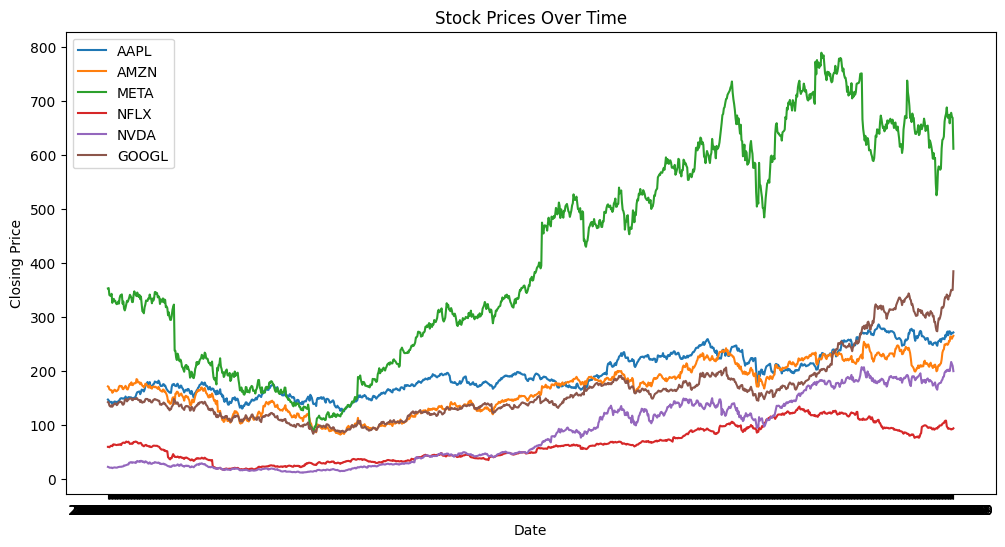

In [29]:
import matplotlib.pyplot as plt

# # Make sure timestamps are datetime
# for df in [daily_aapl, daily_nvda, daily_amzn, daily_googl]:
#     df['timestamp'] = pd.to_datetime(df['timestamp'])
#     df.sort_values('timestamp', inplace=True)

# Plot
plt.figure(figsize=(12,6))

plt.plot(daily_aapl['timestamp'], daily_aapl['close'], label='AAPL')
plt.plot(daily_amzn['timestamp'], daily_amzn['close'], label='AMZN')
plt.plot(daily_meta['timestamp'], daily_meta['close'], label='META')
plt.plot(daily_nflx['timestamp'], daily_nflx['close'], label='NFLX')
plt.plot(daily_nvda['timestamp'], daily_nvda['close'], label='NVDA')
plt.plot(daily_googl['timestamp'], daily_googl['close'], label='GOOGL')


plt.xlabel('Date')
plt.ylabel('Closing Price')
#plt.xticks(rotation=45)
plt.title('Stock Prices Over Time')
plt.legend()

plt.show()

In [15]:
df_daily_data

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,SMA10,SMA20,SMA50,SMA100,prev_close_pct_change,next_close_pct_change
99,2021-09-24,A,172.090,173.080,171.2000,172.40,1.041912e+06,172.4244,15834.0,172.590,174.7785,164.3732,152.4526,-0.214158,-3.491879
100,2021-09-27,A,171.060,171.150,164.2629,166.38,1.419754e+06,166.1472,25590.0,172.020,174.4070,164.7222,152.7827,-3.491879,-3.894699
101,2021-09-28,A,164.190,164.330,158.7900,159.90,2.541015e+06,160.4667,41170.0,170.768,173.5655,164.9686,153.0577,-3.894699,0.062539
102,2021-09-29,A,161.390,161.805,159.8300,160.00,1.268214e+06,160.5194,22512.0,169.389,172.7920,165.1826,153.3187,0.062539,-1.543750
103,2021-09-30,A,161.230,162.480,157.4600,157.53,1.558941e+06,158.5686,21666.0,167.814,171.8960,165.3542,153.5753,-1.543750,-0.977592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985938,2026-04-24,ZYME,27.510,28.300,26.9300,28.10,5.705914e+05,27.9745,11600.0,27.606,26.6725,24.9355,24.8115,2.442581,1.637011
4985939,2026-04-27,ZYME,27.930,29.750,27.9300,28.56,9.502180e+05,28.8344,13412.0,27.845,26.8915,25.0433,24.8368,1.637011,-2.170868
4985940,2026-04-28,ZYME,28.610,28.885,27.9200,27.94,4.214716e+05,28.1324,9773.0,27.941,27.0780,25.1501,24.8652,-2.170868,-0.393701
4985941,2026-04-29,ZYME,27.520,27.950,26.7700,27.83,8.244088e+05,27.7028,13249.0,27.951,27.2175,25.2453,24.8813,-0.393701,-1.042041


In [19]:
stock_groups = {
    'all_stocks': df_daily_data['ticker'].unique().tolist(),
    'faanng_stocks': ['AAPL', 'META', 'GOOGL', 'NVDA', 'NFLX', 'AMZN'],
}

stock_groups['non_faanng_stocks'] = [
    x for x in stock_groups['all_stocks']
    if x not in stock_groups['faanng_stocks']
]

df_group_close_avgs = pd.DataFrame({
    col_name: (
        df_daily_data[df_daily_data['ticker'].isin(tickers)]
        .groupby('timestamp')['prev_close_pct_change']
        .mean()
    )
    for col_name, tickers in stock_groups.items()
}).reset_index()

df_group_close_avgs

,timestamp,all_stocks,faanng_stocks,non_faanng_stocks
0,2021-09-24,-0.261052,0.190078,-0.262020
1,2021-09-27,1.277569,-0.687191,1.281782
2,2021-09-28,-1.888390,-3.051774,-1.885895
3,2021-09-29,-0.440734,0.089050,-0.441870
4,2021-09-30,-0.664913,0.144258,-0.666648
...,...,...,...,...
1149,2026-04-24,0.346018,1.762450,0.342981
1150,2026-04-27,-0.037243,0.457256,-0.038303
1151,2026-04-28,-0.357524,-0.203520,-0.357854
1152,2026-04-29,-1.111793,-0.199965,-1.113749


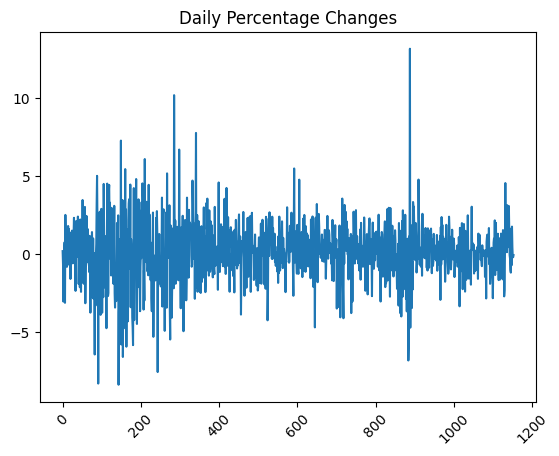

In [23]:
df_group_close_avgs['faanng_stocks'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('Daily Percentage Changes')
plt.show()

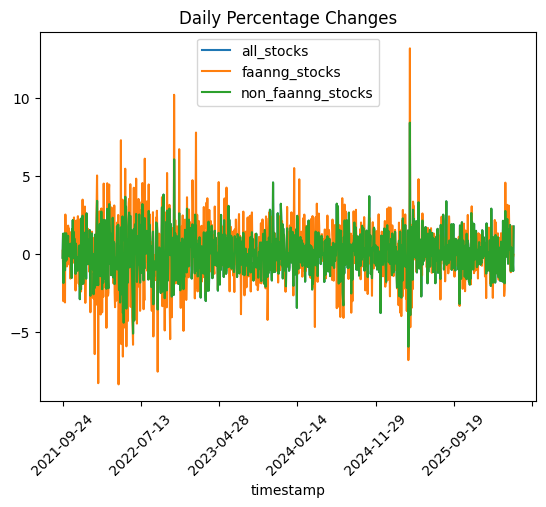

In [21]:
df_group_close_avgs.set_index('timestamp').plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('Daily Percentage Changes')
plt.show()

6. Repeat the same analysis for negative daily moves, such as:
-2%, -3%, -4%, and -5%.

7. Repeat both of the above analyses again using 5 years of historical data.

8. Create a comparison table for the five selected stocks.
Include a simple correlation / collinearity analysis between them.

9. Plot a comparison chart for two to five stocks using daily data for one year.
Example: compare Apple and Amazon.
Normalize or rescale prices if needed so they can be compared clearly.

10. Create another table for the same five stocks showing the probability that the next day
is positive after:
● 2 consecutive positive days
● 3 consecutive positive days
● 4 consecutive positive days
● 5 consecutive positive days
● 6 consecutive positive days

11. Repeat the same analysis for consecutive negative days.

12. Screen all Nasdaq and NYSE stocks and identify the top 10 trending stocks, ranked
by daily percentage change.

Does this mean - recent days? How many recent days?

Average daily percentage change over a span of time? How long of a span?

Overall change over a span?

13. Repeat the screening, but only include stocks with a market capitalization of $5 billion
or more.

# OLD

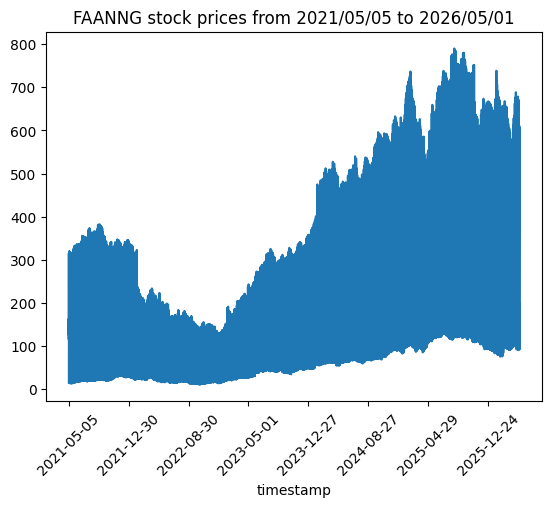

In [61]:
df_faanng.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('FAANNG stock prices from 2021/05/05 to 2026/05/01')
plt.show()